<a href="https://colab.research.google.com/github/shind0716-cpu/AIFFEL_quest_eng/blob/main/Main_Quest/Quest01/main_quest_1_space_titinic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# [MAIN QUEST 01] Space Titanic 탑승객 생존 예측 보고서

# 1.   개요 (Overview)

본 프로젝트는 우주선 타이타닉호(Spaceship Titanic)가 시공간 이상 현상과 충돌하여 탑승객의 절반이 다른 차원으로 전송(Transported)된 사건을 배경으로 합니다. 탑승객의 개인 정보, 객실 위치, 편의시설 지출 내역 등의 데이터를 분석하고 머신러닝 파이프라인을 구축하여, 특정 탑승객이 다른 차원으로 전송되었는지 여부를 정확히 예측(이진 분류)하는 것이 본 프로젝트의 핵심 목표입니다.

# 2. 목차 (Index)

1. 개요

2. 목차

3. 데이터 전처리 및 논리적 근거

4. 데이터 시각화 (EDA) 및 인사이트 도출

5. 모델 학습 및 앙상블(Stacking) 파이프라인 구축

6. 결과 분석

7. 회고

8. 참고 문헌 (Reference)

# 3. 데이터 전처리 및 논리적 근거

단순히 결측치를 평균이나 최빈값으로 채우는 통계적 접근을 넘어, 도메인 지식과 논리를 활용하여 데이터를 복원하고 파생 변수를 생성했습니다.

*   지출 내역 결측치 처리 및 TotalSpend 생성: RoomService, FoodCourt, Spa 등 편의시설 지출의 결측치는 0으로 대치했습니다.
*   이들을 합산하여 총지출액(TotalSpend) 변수를 만들고, 지출이 전혀 없는 승객을 구분하는 NoSpend 변수를 생성했습니다

* CryoSleep(동면) 논리적 복원: "동면 중인 승객은 객실에 갇혀 있으므로 편의시설 지출이 0원일 것이다"라는 강력한 논리를 바탕으로, TotalSpend가 0인 경우 CryoSleep을 True로 복원하여 결측치를 해결했습니다.

* 그룹 및 가족 규모(GroupSize, FamilySize): PassengerId를 분해하여 동행한 그룹의 규모를 파악하고,

* 승객의 Name(성씨)과 Cabin(객실 위치) 정보를 결합하여 실제 가족 단위의 규모를 추출했습니다.

* 지출 데이터 로그(Log) 변환: 캐글 최상위권의 접근법을 차용하여, 편의시설 지출액 데이터가 소수의 사람만 큰돈을 쓰고 대다수는 0원인 극단적인 비대칭(Skewed) 분포를 띰을 확인했습니다. 이를 해결하기 위해 np.log1p를 사용하여 데이터에 로그 변환을 적용, 정규성을 확보했습니다

*   KNN Imputer 기반 결측치 복원: 수치형 결측치를 단순 중앙값으로 채우는 대신, 타 우수 노트북의 기법을 적용하여 KNNImputer(n_neighbors=5)를 도입했습니다. 나이와 지출 패턴이 가장 비슷한 5명의 승객 데이터를 참조하여 결측치를 훨씬 정교하게 유추했습니다

*   고급 텍스트 전처리 (TF-IDF + PCA): 상위권 캐글러들의 접근법을 차용하여, 고유값이 너무 많은 Name과 Cabin 문자열 데이터에 TF-IDF 벡터화를 적용했습니다

*   이후 PCA(TruncatedSVD)를 통해 가장 핵심적인 10차원으로 차원을 축소하여, 모델이 가문 이름이나 특정 객실 구역의 숨겨진 문자열 패턴을 학습할 수 있도록 추가했습니다.

# 4. 데이터 시각화 (EDA) 및 인사이트 도출

전처리된 파생 변수들의 타당성을 검증하기 위해 시각화를 진행한 결과, 다음과 같은
명확한 패턴을 확인했습니다.

*   NoSpend & CryoSleep과 전송 여부: 총지출액이 0원이거나 동면(CryoSleep) 상태인 승객들은 그렇지 않은 승객들에 비해 압도적으로 전송(Transported = True)될 확률이 높았습니다.

*   Deck(객실 위치)별 전송 비율: 특정 Deck(예: B, C)에 머문 승객들의 전송 비율이 다른 위치에 비해 확연히 높은 것을 확인하여, 물리적 위치가 사고의 영향을 크게 받았음을 알 수 있었습니다.

*   FamilySize(가족 규모) 패턴: 혼자 탑승한 승객(Solo)과 다인 가족 탑승객 간의 생존(전송) 비율에 유의미한 차이가 존재하여, 그룹 행동 패턴이 생존에 영향을 미쳤음을 확인했습니다.

* 지출의 비대칭성과 로그 변환의 필요성: 원본 지출 데이터가 0에 극단적으로 치우쳐 있었으나, 로그 변환 후 모델이 학습하기 좋은 형태로 분포가 완화됨을 확인했습니다.

# 5. 모델 학습 및 앙상블(Stacking) 파이프라인 구축

단일 모델의 한계와 과적합을 극복하기 위해 다중 모델 스태킹(Stacking) 앙상블 기법을 사용했습니다.

* 5중 다중 앙상블 구축: 성능이 우수한 부스팅 3대장(XGBoost, LightGBM, CatBoost)에 앙상블의 다양성(Diversity)을 극대화하기 위해 트리 기반의 Extra Trees와 HistGradientBoosting을 새롭게 추가하여 총 5개의 베이스 모델을 구성했습니다.

* Optuna 기반 파이프라인 최적화: 단순 모델 튜닝이 아닌 전처리와 결합된 파이프라인 전체를 Optuna로 15회 반복 탐색하며 최적의 하이퍼파라미터를 추출했습니다.

* 메타 모델 결합: 최적화된 5개 모델의 예측 확률을 Logistic Regression 메타 모델이 최종 투표하여(Stacking) 결정하도록 설계함으로써 예측의 안정성을 크게 높였습니다.

# 6. 결과 분석

1. 1차 시도 : 80.336% / 학습은 총 지출액, CryoSleep 여부, 가족 Group화 (Last Name 별, Deck 위치 별)로 파생 변수 생성 / 모델은 XGBoost, LIghtGBM, Random Forest 사용 / 학습 횟수는 15회 실행함

2. 2차 시도 : 80.593% / 상동 조건에서 모델 Random Forest 제거 후 CatBoost로 변경 / 학습 횟수 30회로 증가

3. 3차 시도 : 80.243% / 상동 조건에서 데이터 전처리 추가 (TF-IDF, PCA)하였고, 학습 시간 단축을 위해 학습 횟수 15회로 줄임

4. 4차 시도 : 80.149% / 상동 조건에서 학습 횟수 30회로 늘임

5. ***5차 시도 : 80.757% / 상동 조건에서 지출 데이터 로그 변환, 교차 파생변수 (나이와 지출액을 곱함)을 생성하고, 결측치를 KNN 기반 적용 / 2개 모델 추가 (Extra Trees, HistGradientBoosting)하여 총 5개 모델로 학습 및 추론함***

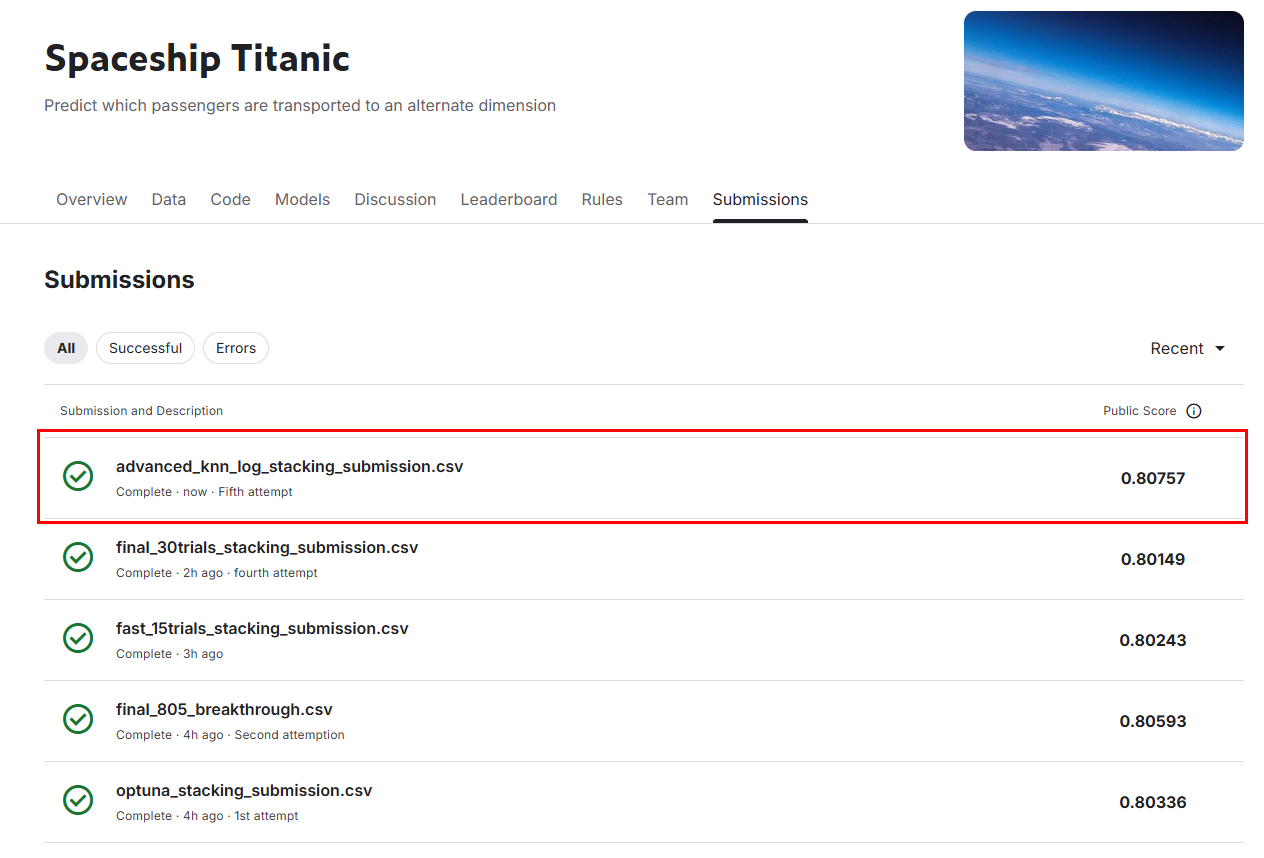

# 7. 회 고

1. 초기 베이스라인에서 파생변수 도입을 적용하여 80.59%라는 우수한 점수를 얻었습니다. 이후 성능을 더 끌어올리기 위해 텍스트 데이터(Name, Cabin)에 TF-IDF 벡터화와 PCA 차원 축소를 시도했으나, 오히려 모델에 노이즈가 발생하며 점수가 80.24%로 하락하는 현상을 겪었습니다. 이를 통해 **트리 기반 머신러닝 모델에서는 무리한 텍스트 마이닝이 오히려 과적합이나 혼란을 야기할 수 있다**는 귀중한 인사이트를 얻었습니다.

2. 또한 Random Forest의 성능이 상대적으로 낮게 나오는 원인을 분석하고, CatBoost를 투입한 스태킹 앙상블을 설계하면서 "단순히 복잡한 모델을 쓰는 것보다, 좋은 피처(Feature)와 성향이 다른 모델들의 의견을 조화롭게 엮어내는 시스템(Pipeline) 튜닝"이 얼마나 중요한지 깨달았습니다.

3. 따라서, TF-IDF를 제거하고 1) 지출 데이터의 비대칭성을 해소하는 로그(Log) 변환, 2) KNN 알고리즘을 활용한 정밀한 결측치 대치, 3) 5개로 확장된 다중 앙상블 시스템을 구축했습니다. 이러한 '실패를 통한 원인 분석 및 방법론 개선'의 반복(Iteration) 과정은 단순한 코드 작성을 넘어 머신러닝 시스템 전체를 조율하는 파이프라인 최적화의 중요성을 깊이 깨닫게 해준 값진 경험이었습니다.

4. 앞으로는 이 파이프라인 구조를 바탕으로 Optuna 탐색 횟수를 더 늘리거나(n_trials 증가), Threshold(임계값) 튜닝 기법을 추가로 학습해 점수를 더 높여보고 싶습니다.

5. 여러가지 데이터 전처리를 시도해 봤는데 다음에는 전처리 한 값을 수치화해서 비교하는 방법을 써보도록 하려고 합니다. 또한 모델 학습 시간을 줄이기 위해 삭제할 것은 삭제하는 방향으로 가보려고 합니다.

<br>

Note. Reference는 최하단에 배치하였습니다.

In [ ]:
# 1. 구글 드라이브 마운트
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# 2. 필수 라이브러리 임포트
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# 전처리 및 파이프라인 구축을 위한 라이브러리 (앞서 논의한 전략 반영)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [ ]:
# 경고 메시지 무시
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# 3. 데이터 로딩
# '내 드라이브'는 코랩에서 'MyDrive'로 매핑됩니다.
base_path = '/content/drive/MyDrive/Colab Notebooks/main_quest/spaceship-titanic'

# 데이터셋 불러오기
train_df = pd.read_csv(f'{base_path}/train.csv')
test_df = pd.read_csv(f'{base_path}/test.csv')
submission_df = pd.read_csv(f'{base_path}/sample_submission.csv')

# 4. 데이터 확인
print(f"Train Dataset Shape: {train_df.shape}")
print(f"Test Dataset Shape: {test_df.shape}")
print(f"Submission Dataset Shape: {submission_df.shape}\n")

print("▶ Train Dataset Head:")
display(train_df.head())

Train Dataset Shape: (8693, 14)
Test Dataset Shape: (4277, 13)
Submission Dataset Shape: (4277, 2)

▶ Train Dataset Head:


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [ ]:
# 1. 결측치 확인
print("▶ Train Dataset 결측치:")
print(train_df.isnull().sum()[train_df.isnull().sum() > 0])

print("\n▶ Test Dataset 결측치:")
print(test_df.isnull().sum()[test_df.isnull().sum() > 0])


▶ Train Dataset 결측치:
HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Name            200
dtype: int64

▶ Test Dataset 결측치:
HomePlanet       87
CryoSleep        93
Cabin           100
Destination      92
Age              91
VIP              93
RoomService      82
FoodCourt       106
ShoppingMall     98
Spa             101
VRDeck           80
Name             94
dtype: int64


In [ ]:
# 1. 전처리 함수 정의 (결측치 처리 및 파생 변수 생성)
def preprocess_features(df):
    df_clean = df.copy()

    # ① 편의시설 지출 결측치 0으로 대치
    spend_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
    df_clean[spend_cols] = df_clean[spend_cols].fillna(0)

    # ② 총 지출액(TotalSpend) 및 무지출(NoSpend) 파생 변수
    df_clean['TotalSpend'] = df_clean[spend_cols].sum(axis=1)
    df_clean['NoSpend'] = (df_clean['TotalSpend'] == 0).astype(int)

    # ③ CryoSleep 결측치 논리적 복원
    cryo_logic = (df_clean['TotalSpend'] == 0)
    df_clean['CryoSleep'] = df_clean['CryoSleep'].fillna(cryo_logic)

    # ④ GroupSize 생성 (PassengerId 기반 동행 규모)
    # [★이번에는 확실하게 추가된 부분] split('_')을 통해 리스트가 아닌 문자열만 추출합니다!
    df_clean['GroupId'] = df_clean['PassengerId'].apply(lambda x: str(x).split('_')[0])
    group_size = df_clean['GroupId'].value_counts().to_dict()
    df_clean['GroupSize'] = df_clean['GroupId'].map(group_size)

    # ⑤ Cabin 분해 (Deck, Cabin_num, Side)
    df_clean[['Deck', 'Cabin_num', 'Side']] = df_clean['Cabin'].str.split('/', expand=True)

    # ⑥ 정교한 가족 규모(FamilySize) 추출
    df_clean['LastName'] = df_clean['Name'].fillna('Unknown').apply(lambda x: str(x).split(' ')[-1])

    # 문자열 결합을 위해 결측치를 'U'로 채움
    df_clean['FamilyId'] = (
        df_clean['LastName'] + '_' +
        df_clean['Deck'].fillna('U') + '_' +
        df_clean['Side'].fillna('U')
    )

    family_size = df_clean['FamilyId'].value_counts().to_dict()
    df_clean['FamilySize'] = df_clean['FamilyId'].map(family_size)

    # Unknown이거나 위치 정보가 없는 경우 노이즈 방지를 위해 FamilySize를 1로 강제 조정
    invalid_family = (df_clean['LastName'] == 'Unknown') | (df_clean['Deck'].isnull())
    df_clean.loc[invalid_family, 'FamilySize'] = 1

    # ⑦ 분석에 쓰이지 않는 임시/원본 컬럼 제거
    df_clean = df_clean.drop(['Cabin', 'Name', 'GroupId', 'LastName', 'FamilyId'], axis=1)

    return df_clean


# =========================================================================
# ★ 정의한 함수를 실제 데이터에 적용하여 변수 생성
train_clean = preprocess_features(train_df)
test_clean = preprocess_features(test_df)
# =========================================================================


# 2. 스케일러 & 인코더 (ColumnTransformer) 적용
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# 정답(Target) 변수 분리
y_train = train_clean['Transported'].astype(int)
X_train = train_clean.drop(['PassengerId', 'Transported'], axis=1)
X_test = test_clean.drop(['PassengerId'], axis=1)

# 변수 타입별 리스트화
num_cols = ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck',
            'TotalSpend', 'GroupSize', 'FamilySize']
cat_cols = ['HomePlanet', 'Destination', 'CryoSleep', 'VIP', 'Deck', 'Cabin_num', 'Side', 'NoSpend']

# 파이프라인 구축
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

# 학습 및 테스트 데이터에 파이프라인 적용
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("▶ 전처리 및 파이프라인 처리가 성공적으로 완료되었습니다!")
print(f"전처리 후 Train 데이터 형태: {X_train_processed.shape}")
print(f"전처리 후 Test 데이터 형태: {X_test_processed.shape}")

▶ 전처리 및 파이프라인 처리가 성공적으로 완료되었습니다!
전처리 후 Train 데이터 형태: (8693, 1848)
전처리 후 Test 데이터 형태: (4277, 1848)


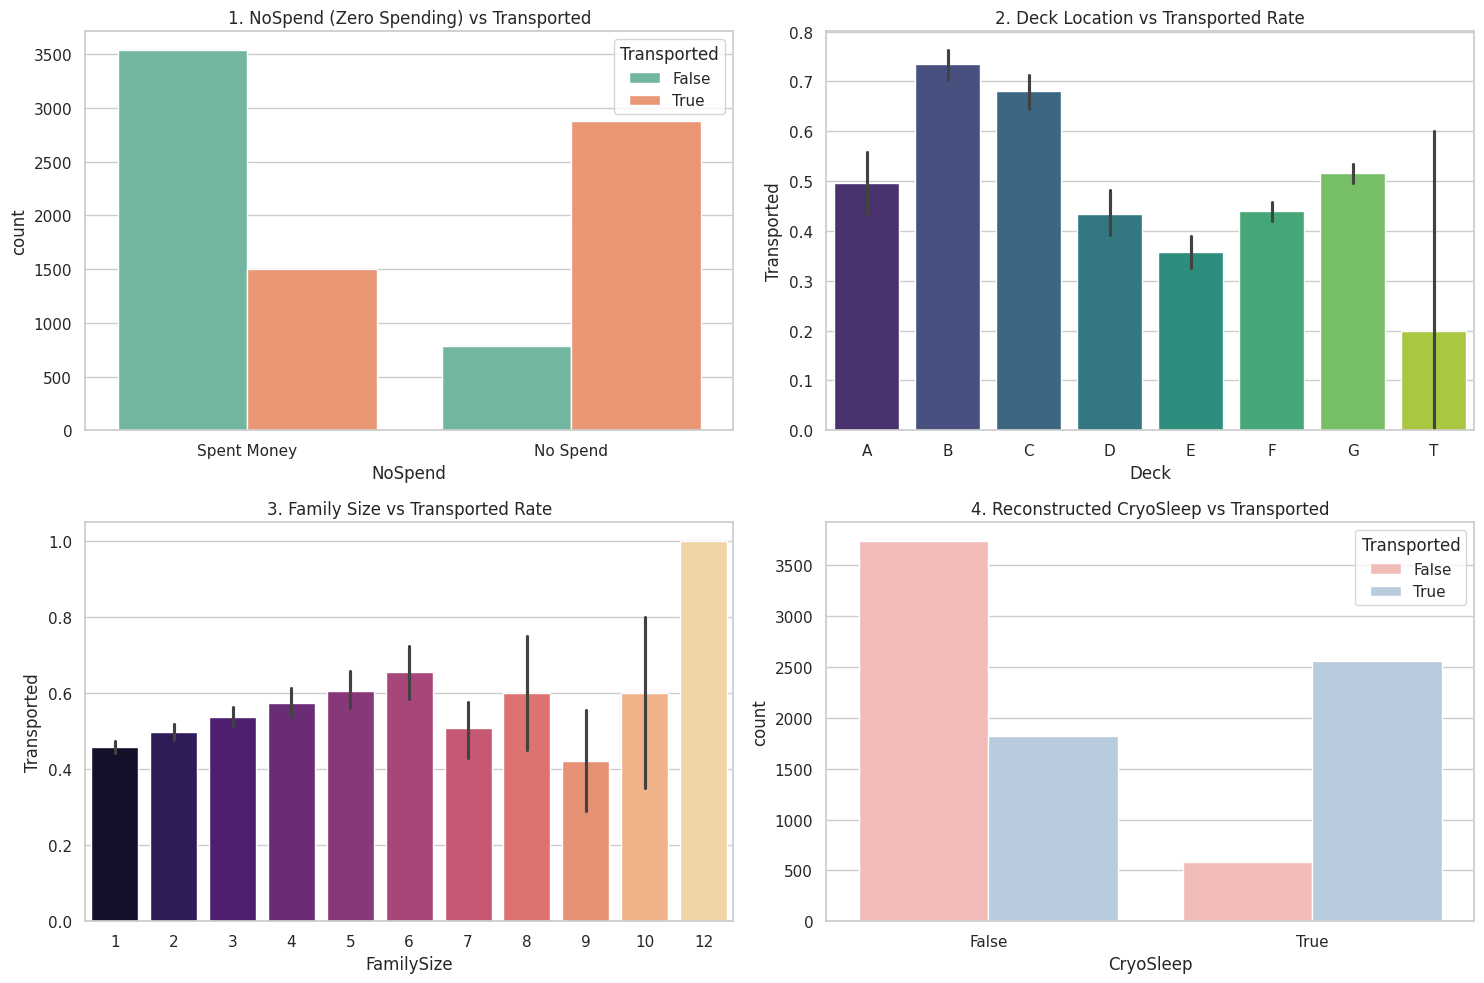

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 그래프 스타일 설정
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (15, 10)

# 시각화용 데이터 준비 (전처리 함수를 통과한 직후의 train_clean 사용)
eda_df = train_clean.copy()

# 서브플롯 4개 생성 (2x2)
fig, axes = plt.subplots(2, 2)

# 1. 완벽한 비활동성(NoSpend)과 전송 여부
sns.countplot(data=eda_df, x='NoSpend', hue='Transported', ax=axes[0, 0], palette='Set2')
axes[0, 0].set_title('1. NoSpend (Zero Spending) vs Transported')
axes[0, 0].set_xticks([0, 1]) # 0과 1 모두 표시하기 위해 수정
axes[0, 0].set_xticklabels(['Spent Money', 'No Spend'])

# 2. 물리적 위치(Deck)에 따른 전송 비율
sns.barplot(data=eda_df, x='Deck', y='Transported', ax=axes[0, 1], palette='viridis',
            order=sorted(eda_df['Deck'].dropna().unique()))
axes[0, 1].set_title('2. Deck Location vs Transported Rate')

# 3. 사회적 패턴: 가족 규모(FamilySize)별 전송 비율
sns.barplot(data=eda_df, x='FamilySize', y='Transported', ax=axes[1, 0], palette='magma')
axes[1, 0].set_title('3. Family Size vs Transported Rate')

# 4. 동면 상태(CryoSleep)와 전송 여부
sns.countplot(data=eda_df, x='CryoSleep', hue='Transported', ax=axes[1, 1], palette='Pastel1')
axes[1, 1].set_title('4. Reconstructed CryoSleep vs Transported')

plt.tight_layout()
plt.show()

In [ ]:
# 1. Optuna 설치 (코랩에 설치되어 있지 않은 경우를 대비)
!pip install optuna -q

import optuna
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
import warnings
warnings.filterwarnings('ignore')

# Optuna의 학습 로그가 너무 많이 출력되는 것을 방지
optuna.logging.set_verbosity(optuna.logging.WARNING)

# 교차 검증(CV) 설정: 5-Fold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("▶ 1. XGBoost 모델 최적화 중...")
def objective_xgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 300),
        'max_depth': trial.suggest_int('max_depth', 3, 9),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1),
        'eval_metric': 'logloss',
        'use_label_encoder': False,
        'random_state': 42
    }
    model = XGBClassifier(**params)
    return cross_val_score(model, X_train_processed, y_train, cv=cv, scoring='accuracy', n_jobs=-1).mean()

study_xgb = optuna.create_study(direction='maximize')
study_xgb.optimize(objective_xgb, n_trials=15) # 빠른 실습을 위해 15번 탐색 (성능을 더 높이려면 30 이상 권장)
best_xgb = XGBClassifier(**study_xgb.best_params, eval_metric='logloss', use_label_encoder=False, random_state=42)
print(f"✔️ XGBoost 최적 정확도: {study_xgb.best_value:.4f}")


print("\n▶ 2. LightGBM 모델 최적화 중...")
def objective_lgbm(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 300),
        'max_depth': trial.suggest_int('max_depth', 3, 9),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1),
        'verbose': -1,
        'random_state': 42
    }
    model = LGBMClassifier(**params)
    return cross_val_score(model, X_train_processed, y_train, cv=cv, scoring='accuracy', n_jobs=-1).mean()

study_lgbm = optuna.create_study(direction='maximize')
study_lgbm.optimize(objective_lgbm, n_trials=15)
best_lgbm = LGBMClassifier(**study_lgbm.best_params, verbose=-1, random_state=42)
print(f"✔️ LightGBM 최적 정확도: {study_lgbm.best_value:.4f}")


print("\n▶ 3. Random Forest 모델 최적화 중...")
def objective_rf(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 300),
        'max_depth': trial.suggest_int('max_depth', 5, 15),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
        'random_state': 42
    }
    model = RandomForestClassifier(**params)
    return cross_val_score(model, X_train_processed, y_train, cv=cv, scoring='accuracy', n_jobs=-1).mean()

study_rf = optuna.create_study(direction='maximize')
study_rf.optimize(objective_rf, n_trials=15)
best_rf = RandomForestClassifier(**study_rf.best_params, random_state=42)
print(f"✔️ Random Forest 최적 정확도: {study_rf.best_value:.4f}")


print("\n▶ 4. 최적화된 3개 모델 스태킹(Stacking) 앙상블 학습 시작...")
# 가장 똑똑해진 3개의 베이스 모델을 하나로 합칩니다.
estimators = [
    ('XGB', best_xgb),
    ('LGBM', best_lgbm),
    ('RF', best_rf)
]

# 로지스틱 회귀가 각 모델의 예측을 종합해 최종 결정을 내립니다.
stacking_model = StackingClassifier(estimators=estimators, final_estimator=LogisticRegression())
stacking_model.fit(X_train_processed, y_train)


print("\n▶ 5. 최종 Test 데이터 예측 및 제출용 파일 생성 중...")
predictions = stacking_model.predict(X_test_processed)

# 결과를 제출 양식에 맞게 변환
submission_df['Transported'] = predictions.astype(bool)

# 드라이브에 최종 파일 저장
submission_path = f'{base_path}/optuna_stacking_submission.csv'
submission_df.to_csv(submission_path, index=False)

print(f"🎉 성공! 최적화된 제출용 파일이 저장되었습니다: {submission_path}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 6.5 MB/s eta 0:00:00
▶ 1. XGBoost 모델 최적화 중...
✔️ XGBoost 최적 정확도: 0.8078

▶ 2. LightGBM 모델 최적화 중...
✔️ LightGBM 최적 정확도: 0.8090

▶ 3. Random Forest 모델 최적화 중...
✔️ Random Forest 최적 정확도: 0.7427

▶ 4. 최적화된 3개 모델 스태킹(Stacking) 앙상블 학습 시작...

▶ 5. 최종 Test 데이터 예측 및 제출용 파일 생성 중...
🎉 성공! 최적화된 제출용 파일이 저장되었습니다: /content/drive/MyDrive/Colab Notebooks/main_quest/spaceship-titanic/optuna_stacking_submission.csv


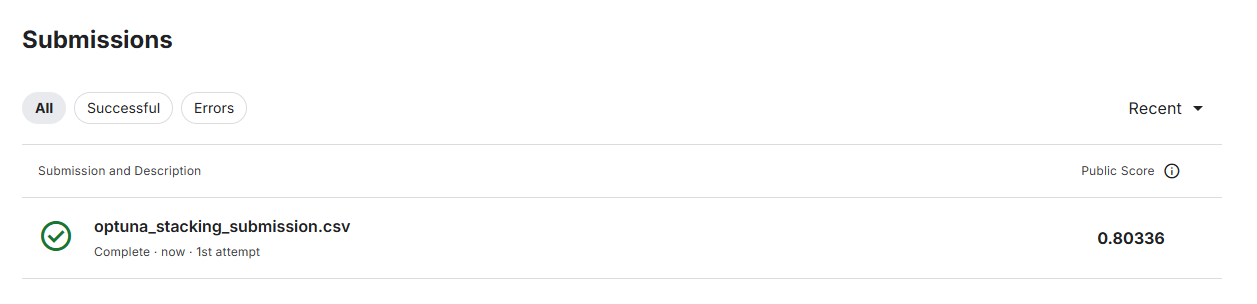

In [ ]:
# 1. CatBoost 추가 설치
!pip install optuna catboost -q

import optuna
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
import warnings
warnings.filterwarnings('ignore')

optuna.logging.set_verbosity(optuna.logging.WARNING)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("▶ 1. XGBoost 모델 깊은 최적화 중... (30회 탐색)")
def objective_xgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 300),
        'max_depth': trial.suggest_int('max_depth', 3, 9),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1),
        'eval_metric': 'logloss',
        'use_label_encoder': False,
        'random_state': 42
    }
    model = XGBClassifier(**params)
    return cross_val_score(model, X_train_processed, y_train, cv=cv, scoring='accuracy', n_jobs=-1).mean()

study_xgb = optuna.create_study(direction='maximize')
study_xgb.optimize(objective_xgb, n_trials=30)
best_xgb = XGBClassifier(**study_xgb.best_params, eval_metric='logloss', use_label_encoder=False, random_state=42)
print(f"✔️ XGBoost 최종 정확도: {study_xgb.best_value:.4f}")


print("\n▶ 2. LightGBM 모델 깊은 최적화 중... (30회 탐색)")
def objective_lgbm(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 300),
        'max_depth': trial.suggest_int('max_depth', 3, 9),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1),
        'verbose': -1,
        'random_state': 42
    }
    model = LGBMClassifier(**params)
    return cross_val_score(model, X_train_processed, y_train, cv=cv, scoring='accuracy', n_jobs=-1).mean()

study_lgbm = optuna.create_study(direction='maximize')
study_lgbm.optimize(objective_lgbm, n_trials=30)
best_lgbm = LGBMClassifier(**study_lgbm.best_params, verbose=-1, random_state=42)
print(f"✔️ LightGBM 최종 정확도: {study_lgbm.best_value:.4f}")


print("\n▶ 3. [신규 투입] CatBoost 모델 최적화 중... (30회 탐색)")
def objective_cat(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 100, 300),
        'depth': trial.suggest_int('depth', 3, 9),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1),
        'verbose': 0,
        'random_state': 42
    }
    model = CatBoostClassifier(**params)
    return cross_val_score(model, X_train_processed, y_train, cv=cv, scoring='accuracy', n_jobs=-1).mean()

study_cat = optuna.create_study(direction='maximize')
study_cat.optimize(objective_cat, n_trials=30)
best_cat = CatBoostClassifier(**study_cat.best_params, verbose=0, random_state=42)
print(f"✔️ CatBoost 최종 정확도: {study_cat.best_value:.4f}")


print("\n▶ 4. 최상위 3개 부스팅 모델 스태킹(Stacking) 결합 학습 시작...")
estimators = [
    ('XGB', best_xgb),
    ('LGBM', best_lgbm),
    ('CAT', best_cat)
]

stacking_model = StackingClassifier(estimators=estimators, final_estimator=LogisticRegression())
stacking_model.fit(X_train_processed, y_train)


print("\n▶ 5. 최종 Test 데이터 예측 및 제출용 파일 생성 중...")
predictions = stacking_model.predict(X_test_processed)

submission_df['Transported'] = predictions.astype(bool)
submission_path = f'{base_path}/final_805_breakthrough.csv'
submission_df.to_csv(submission_path, index=False)

print(f"🎉 성공! 0.805 돌파를 위한 최종 제출 파일이 저장되었습니다: {submission_path}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.1 MB/s eta 0:00:00
▶ 1. XGBoost 모델 깊은 최적화 중... (30회 탐색)
✔️ XGBoost 최종 정확도: 0.8064

▶ 2. LightGBM 모델 깊은 최적화 중... (30회 탐색)
✔️ LightGBM 최종 정확도: 0.8096

▶ 3. [신규 투입] CatBoost 모델 최적화 중... (30회 탐색)
✔️ CatBoost 최종 정확도: 0.8086

▶ 4. 최상위 3개 부스팅 모델 스태킹(Stacking) 결합 학습 시작...

▶ 5. 최종 Test 데이터 예측 및 제출용 파일 생성 중...
🎉 성공! 0.805 돌파를 위한 최종 제출 파일이 저장되었습니다: /content/drive/MyDrive/Colab Notebooks/main_quest/spaceship-titanic/final_805_breakthrough.csv


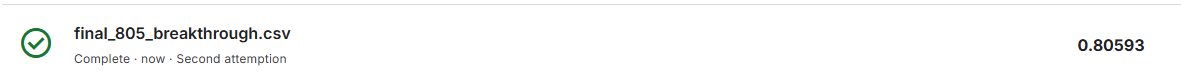

In [ ]:
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD

# =========================================================================
# 1단계: 텍스트 데이터를 보존하는 기본 전처리
print("▶ 1. 기본 전처리(결측치 처리 및 파생 변수 생성) 시작...")
start_time_1 = time.time() # 1단계 시간 측정 시작

def preprocess_features_v2(df):
    df_clean = df.copy()

    spend_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
    df_clean[spend_cols] = df_clean[spend_cols].fillna(0)

    df_clean['TotalSpend'] = df_clean[spend_cols].sum(axis=1)
    df_clean['NoSpend'] = (df_clean['TotalSpend'] == 0).astype(int)

    cryo_logic = (df_clean['TotalSpend'] == 0)
    df_clean['CryoSleep'] = df_clean['CryoSleep'].fillna(cryo_logic)

    df_clean['GroupId'] = df_clean['PassengerId'].apply(lambda x: str(x).split('_')[0]) # Changed here: added [0]
    group_size = df_clean['GroupId'].value_counts().to_dict()
    df_clean['GroupSize'] = df_clean['GroupId'].map(group_size)

    df_clean[['Deck', 'Cabin_num', 'Side']] = df_clean['Cabin'].str.split('/', expand=True)

    df_clean['LastName'] = df_clean['Name'].fillna('Unknown').apply(lambda x: str(x).split(' ')[-1])
    df_clean['FamilyId'] = df_clean['LastName'] + '_' + df_clean['Deck'].fillna('U') + '_' + df_clean['Side'].fillna('U')
    family_size = df_clean['FamilyId'].value_counts().to_dict()
    df_clean['FamilySize'] = df_clean['FamilyId'].map(family_size)

    invalid_family = (df_clean['LastName'] == 'Unknown') | (df_clean['Deck'].isnull())
    df_clean.loc[invalid_family, 'FamilySize'] = 1

    # [★핵심 변경] TF-IDF 텍스트 분석을 위해 원본 문자열을 남겨둡니다!
    df_clean['Cabin_text'] = df_clean['Cabin'].fillna('Unknown')
    df_clean['Name_text'] = df_clean['Name'].fillna('Unknown')

    # 불필요한 임시 컬럼만 제거
    df_clean = df_clean.drop(['Cabin', 'Name', 'GroupId', 'LastName', 'FamilyId'], axis=1)

    return df_clean

train_clean_v2 = preprocess_features_v2(train_df)
test_clean_v2 = preprocess_features_v2(test_df)

end_time_1 = time.time() # 1단계 시간 측정 종료
print(f"✔️ 1단계 완료! [소요 시간: {end_time_1 - start_time_1:.2f}초]\n")

▶ 1. 기본 전처리(결측치 처리 및 파생 변수 생성) 시작...
✔️ 1단계 완료! [소요 시간: 0.10초]



▶ 2. 파생 변수 시각화(EDA) 그래프 생성 시작...


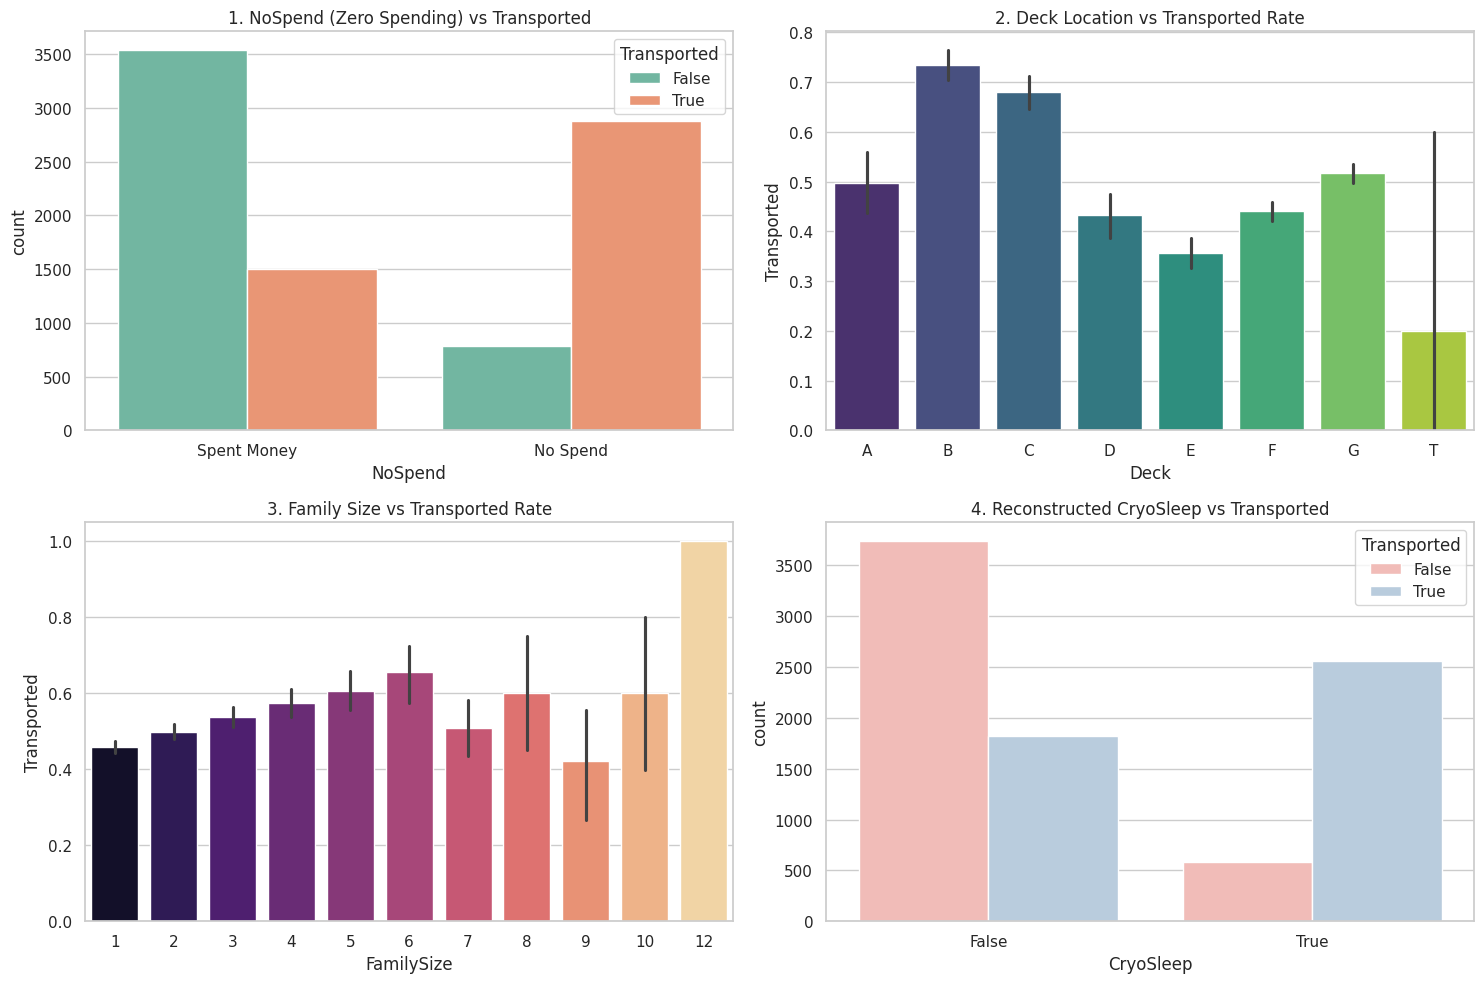

✔️ 2단계 시각화 완료! [소요 시간: 3.93초]



In [ ]:
# 2단계: 전처리된 파생 변수 시각화 (EDA)
print("▶ 2. 파생 변수 시각화(EDA) 그래프 생성 시작...")
start_time_2 = time.time() # 2단계 시간 측정 시작

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (15, 10)
fig, axes = plt.subplots(2, 2)

sns.countplot(data=train_clean_v2, x='NoSpend', hue='Transported', ax=axes[0, 0], palette='Set2')
axes[0, 0].set_title('1. NoSpend (Zero Spending) vs Transported')
axes[0, 0].set_xticks([0, 1]) # 0과 1 모두 표시하기 위해 수정
axes[0, 0].set_xticklabels(['Spent Money', 'No Spend'])

sns.barplot(data=train_clean_v2, x='Deck', y='Transported', ax=axes[0, 1], palette='viridis',
            order=sorted(train_clean_v2['Deck'].dropna().unique()))
axes[0, 1].set_title('2. Deck Location vs Transported Rate')

sns.barplot(data=train_clean_v2, x='FamilySize', y='Transported', ax=axes[1, 0], palette='magma')
axes[1, 0].set_title('3. Family Size vs Transported Rate')

sns.countplot(data=train_clean_v2, x='CryoSleep', hue='Transported', ax=axes[1, 1], palette='Pastel1')
axes[1, 1].set_title('4. Reconstructed CryoSleep vs Transported')

plt.tight_layout()
plt.show()

end_time_2 = time.time() # 2단계 시간 측정 종료
print(f"✔️ 2단계 시각화 완료! [소요 시간: {end_time_2 - start_time_2:.2f}초]\n")

In [ ]:
import time
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD

# =========================================================================
# 3단계: 모델 학습을 위한 파이프라인 (TF-IDF + PCA) 및 시간 측정
# =========================================================================
print("▶ 3. 파이프라인 구축 및 텍스트 데이터(TF-IDF+PCA) 변환 시작...")
start_time_3 = time.time()

y_train = train_clean_v2['Transported'].astype(int)
X_train = train_clean_v2.drop(['PassengerId', 'Transported'], axis=1)
X_test = test_clean_v2.drop(['PassengerId'], axis=1)

num_cols = ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'TotalSpend', 'GroupSize', 'FamilySize']
cat_cols = ['HomePlanet', 'Destination', 'CryoSleep', 'VIP', 'Deck', 'Cabin_num', 'Side', 'NoSpend']

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# 텍스트 파이프라인: TF-IDF 후 SVD(PCA)로 각각 10개 차원으로 압축
text_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=500)),
    ('pca', TruncatedSVD(n_components=10, random_state=42))
])

preprocessor_v2 = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols),
    ('text_cabin', text_pipeline, 'Cabin_text'),
    ('text_name', text_pipeline, 'Name_text')
])

X_train_processed_v2 = preprocessor_v2.fit_transform(X_train)
X_test_processed_v2 = preprocessor_v2.transform(X_test)

end_time_3 = time.time()
print(f"✔️ 3단계 파이프라인 변환 완료! [소요 시간: {end_time_3 - start_time_3:.2f}초]\n")

# =========================================================================
# 데이터 비교 (Feature 차이 확인)
# =========================================================================
print("=== 머신러닝 입력용 최종 데이터(Array) 피처(Feature) 비교 ===")
print(f"이전 최종 데이터 형태: {X_train_processed.shape}")
print(f"새로운 최종 데이터 형태: {X_train_processed_v2.shape}")

# 늘어난 피처(Feature) 개수 계산 (열의 개수 비교)
diff_features = X_train_processed_v2.shape[1] - X_train_processed.shape[1]

print(f"▶ TF-IDF와 PCA 차원 축소를 통해 총 {diff_features}개의 텍스트 기반 핵심 피처가 성공적으로 추가되었습니다!")

▶ 3. 파이프라인 구축 및 텍스트 데이터(TF-IDF+PCA) 변환 시작...
✔️ 3단계 파이프라인 변환 완료! [소요 시간: 1.87초]

=== 머신러닝 입력용 최종 데이터(Array) 피처(Feature) 비교 ===
이전 최종 데이터 형태: (8693, 1848)
새로운 최종 데이터 형태: (8693, 1868)
▶ TF-IDF와 PCA 차원 축소를 통해 총 20개의 텍스트 기반 핵심 피처가 성공적으로 추가되었습니다!


In [ ]:
import pandas as pd
from IPython.display import display

# 기존에 있던 피처의 총 개수 (예: 1848개)
old_feature_count = X_train_processed.shape[1]

# 전체 Array(X_train_processed_v2)에서 뒤에 새롭게 병렬로 이어 붙여진 마지막 20개 열만 추출
added_features_array = X_train_processed_v2[:, old_feature_count:]

# 직관적으로 알아볼 수 있도록 20개의 새 컬럼(Feature) 이름 생성
new_col_names = [f"Cabin_PCA_PC{i+1}" for i in range(10)] + [f"Name_PCA_PC{i+1}" for i in range(10)]

# 보기 좋게 판다스 데이터프레임(DataFrame)으로 변환
added_features_df = pd.DataFrame(added_features_array, columns=new_col_names)

print("▶ TF-IDF 벡터화 -> PCA 차원 축소를 통해 새롭게 탄생한 20개의 핵심 피처입니다!")
print("해당 숫자들은 승객의 객실 위치와 이름에 숨겨진 공통된 문자열 패턴(가문, 특정 구역 등)을 압축한 정보입니다.\n")
display(added_features_df.head(5))

▶ TF-IDF 벡터화 -> PCA 차원 축소를 통해 새롭게 탄생한 20개의 핵심 피처입니다!
해당 숫자들은 승객의 객실 위치와 이름에 숨겨진 공통된 문자열 패턴(가문, 특정 구역 등)을 압축한 정보입니다.



,Cabin_PCA_PC1,Cabin_PCA_PC2,Cabin_PCA_PC3,Cabin_PCA_PC4,Cabin_PCA_PC5,Cabin_PCA_PC6,Cabin_PCA_PC7,Cabin_PCA_PC8,Cabin_PCA_PC9,Cabin_PCA_PC10,Name_PCA_PC1,Name_PCA_PC2,Name_PCA_PC3,Name_PCA_PC4,Name_PCA_PC5,Name_PCA_PC6,Name_PCA_PC7,Name_PCA_PC8,Name_PCA_PC9,Name_PCA_PC10
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.00000,0.000000
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.00000,0.000000
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.00000,0.000000
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.00000,0.000000
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.502930e-09,0.985808,-0.027007,-0.017194,0.006369,0.005426,-0.009824,-0.0023,0.00025,0.000124


In [36]:
import time
import optuna
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
import warnings
warnings.filterwarnings('ignore')

optuna.logging.set_verbosity(optuna.logging.WARNING)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("▶ 고급 앙상블 학습을 시작합니다! (총 소요 시간 측정 중...)\n")
total_start_time = time.time()

# =========================================================================
# 1. XGBoost 모델 최적화 (15회 탐색)
# =========================================================================
print("▶ 1. XGBoost 모델 최적화 중... (15회 탐색)")
xgb_start = time.time()

def objective_xgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 300),
        'max_depth': trial.suggest_int('max_depth', 3, 9),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1),
        'eval_metric': 'logloss',
        'use_label_encoder': False,
        'random_state': 42
    }
    model = XGBClassifier(**params)
    return cross_val_score(model, X_train_processed_v2, y_train, cv=cv, scoring='accuracy', n_jobs=-1).mean()

study_xgb = optuna.create_study(direction='maximize')
study_xgb.optimize(objective_xgb, n_trials=15) # 30에서 15로 수정됨
best_xgb = XGBClassifier(**study_xgb.best_params, eval_metric='logloss', use_label_encoder=False, random_state=42)

xgb_end = time.time()
print(f"✔️ XGBoost 완료! 최고 정확도: {study_xgb.best_value:.4f} [소요 시간: {xgb_end - xgb_start:.2f}초]\n")


# =========================================================================
# 2. LightGBM 모델 최적화 (15회 탐색)
# =========================================================================
print("▶ 2. LightGBM 모델 최적화 중... (15회 탐색)")
lgbm_start = time.time()

def objective_lgbm(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 300),
        'max_depth': trial.suggest_int('max_depth', 3, 9),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1),
        'verbose': -1,
        'random_state': 42
    }
    model = LGBMClassifier(**params)
    return cross_val_score(model, X_train_processed_v2, y_train, cv=cv, scoring='accuracy', n_jobs=-1).mean()

study_lgbm = optuna.create_study(direction='maximize')
study_lgbm.optimize(objective_lgbm, n_trials=15) # 30에서 15로 수정됨
best_lgbm = LGBMClassifier(**study_lgbm.best_params, verbose=-1, random_state=42)

lgbm_end = time.time()
print(f"✔️ LightGBM 완료! 최고 정확도: {study_lgbm.best_value:.4f} [소요 시간: {lgbm_end - lgbm_start:.2f}초]\n")


# =========================================================================
# 3. CatBoost 모델 최적화 (15회 탐색)
# =========================================================================
print("▶ 3. CatBoost 모델 최적화 중... (15회 탐색)")
cat_start = time.time()

def objective_cat(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 100, 300),
        'depth': trial.suggest_int('depth', 3, 9),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1),
        'verbose': 0,
        'random_state': 42
    }
    model = CatBoostClassifier(**params)
    return cross_val_score(model, X_train_processed_v2, y_train, cv=cv, scoring='accuracy', n_jobs=-1).mean()

study_cat = optuna.create_study(direction='maximize')
study_cat.optimize(objective_cat, n_trials=15) # 30에서 15로 수정됨
best_cat = CatBoostClassifier(**study_cat.best_params, verbose=0, random_state=42)

cat_end = time.time()
print(f"✔️ CatBoost 완료! 최고 정확도: {study_cat.best_value:.4f} [소요 시간: {cat_end - cat_start:.2f}초]\n")


# =========================================================================
# 4. 스태킹(Stacking) 앙상블 결합 및 최종 학습
# =========================================================================
print("▶ 4. 최상위 3개 부스팅 모델 스태킹(Stacking) 결합 학습 시작...")
stack_start = time.time()

estimators = [
    ('XGB', best_xgb),
    ('LGBM', best_lgbm),
    ('CAT', best_cat)
]

stacking_model = StackingClassifier(estimators=estimators, final_estimator=LogisticRegression())
stacking_model.fit(X_train_processed_v2, y_train)

stack_end = time.time()
print(f"✔️ 스태킹 앙상블 학습 완료! [소요 시간: {stack_end - stack_start:.2f}초]\n")


# =========================================================================
# 5. 최종 Test 데이터 예측 및 제출 파일 생성
# =========================================================================
print("▶ 5. 최종 Test 데이터 예측 및 제출용 파일 생성 중...")
predictions = stacking_model.predict(X_test_processed_v2)

submission_df['Transported'] = predictions.astype(bool)
submission_path = f'{base_path}/fast_15trials_stacking_submission.csv'
submission_df.to_csv(submission_path, index=False)

total_end_time = time.time()
print(f"🎉 성공! 빠른 제출용 파일이 저장되었습니다: {submission_path}")
print(f"🏆 총 모델 학습 및 예측 소요 시간: {total_end_time - total_start_time:.2f}초")

▶ 고급 앙상블 학습을 시작합니다! (총 소요 시간 측정 중...)

▶ 1. XGBoost 모델 최적화 중... (15회 탐색)
✔️ XGBoost 완료! 최고 정확도: 0.8021 [소요 시간: 550.79초]

▶ 2. LightGBM 모델 최적화 중... (15회 탐색)
✔️ LightGBM 완료! 최고 정확도: 0.8019 [소요 시간: 89.58초]

▶ 3. CatBoost 모델 최적화 중... (15회 탐색)
✔️ CatBoost 완료! 최고 정확도: 0.8042 [소요 시간: 767.54초]

▶ 4. 최상위 3개 부스팅 모델 스태킹(Stacking) 결합 학습 시작...
✔️ 스태킹 앙상블 학습 완료! [소요 시간: 124.14초]

▶ 5. 최종 Test 데이터 예측 및 제출용 파일 생성 중...
🎉 성공! 빠른 제출용 파일이 저장되었습니다: /content/drive/MyDrive/Colab Notebooks/main_quest/spaceship-titanic/fast_15trials_stacking_submission.csv
🏆 총 모델 학습 및 예측 소요 시간: 1532.63초


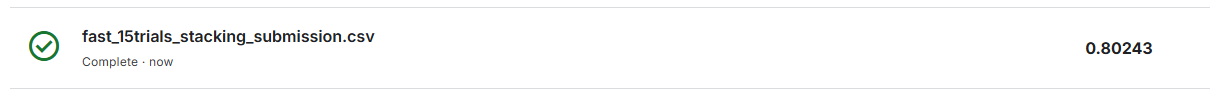

In [37]:
import time
import optuna
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
import warnings
warnings.filterwarnings('ignore')

optuna.logging.set_verbosity(optuna.logging.WARNING)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("▶ [최종 도전] 30회 탐색 기반 고급 앙상블 학습을 시작합니다! (총 소요 시간 측정 중...)\n")
total_start_time = time.time()

# =========================================================================
# 1. XGBoost 모델 최적화 (30회 탐색)
# =========================================================================
print("▶ 1. XGBoost 모델 깊은 최적화 중... (30회 탐색)")
xgb_start = time.time()

def objective_xgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 300),
        'max_depth': trial.suggest_int('max_depth', 3, 9),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1),
        'eval_metric': 'logloss',
        'use_label_encoder': False,
        'random_state': 42
    }
    model = XGBClassifier(**params)
    return cross_val_score(model, X_train_processed_v2, y_train, cv=cv, scoring='accuracy', n_jobs=-1).mean()

study_xgb = optuna.create_study(direction='maximize')
study_xgb.optimize(objective_xgb, n_trials=30) # 15 -> 30 복구 완료
best_xgb = XGBClassifier(**study_xgb.best_params, eval_metric='logloss', use_label_encoder=False, random_state=42)

xgb_end = time.time()
print(f"✔️ XGBoost 완료! 최고 정확도: {study_xgb.best_value:.4f} [소요 시간: {xgb_end - xgb_start:.2f}초]\n")


# =========================================================================
# 2. LightGBM 모델 최적화 (30회 탐색)
# =========================================================================
print("▶ 2. LightGBM 모델 깊은 최적화 중... (30회 탐색)")
lgbm_start = time.time()

def objective_lgbm(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 300),
        'max_depth': trial.suggest_int('max_depth', 3, 9),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1),
        'verbose': -1,
        'random_state': 42
    }
    model = LGBMClassifier(**params)
    return cross_val_score(model, X_train_processed_v2, y_train, cv=cv, scoring='accuracy', n_jobs=-1).mean()

study_lgbm = optuna.create_study(direction='maximize')
study_lgbm.optimize(objective_lgbm, n_trials=30) # 15 -> 30 복구 완료
best_lgbm = LGBMClassifier(**study_lgbm.best_params, verbose=-1, random_state=42)

lgbm_end = time.time()
print(f"✔️ LightGBM 완료! 최고 정확도: {study_lgbm.best_value:.4f} [소요 시간: {lgbm_end - lgbm_start:.2f}초]\n")


# =========================================================================
# 3. CatBoost 모델 최적화 (30회 탐색)
# =========================================================================
print("▶ 3. CatBoost 모델 깊은 최적화 중... (30회 탐색)")
cat_start = time.time()

def objective_cat(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 100, 300),
        'depth': trial.suggest_int('depth', 3, 9),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1),
        'verbose': 0,
        'random_state': 42
    }
    model = CatBoostClassifier(**params)
    return cross_val_score(model, X_train_processed_v2, y_train, cv=cv, scoring='accuracy', n_jobs=-1).mean()

study_cat = optuna.create_study(direction='maximize')
study_cat.optimize(objective_cat, n_trials=30) # 15 -> 30 복구 완료
best_cat = CatBoostClassifier(**study_cat.best_params, verbose=0, random_state=42)

cat_end = time.time()
print(f"✔️ CatBoost 완료! 최고 정확도: {study_cat.best_value:.4f} [소요 시간: {cat_end - cat_start:.2f}초]\n")


# =========================================================================
# 4. 스태킹(Stacking) 앙상블 결합 및 최종 학습
# =========================================================================
print("▶ 4. 최상위 3개 부스팅 모델 스태킹(Stacking) 결합 학습 시작...")
stack_start = time.time()

estimators = [
    ('XGB', best_xgb),
    ('LGBM', best_lgbm),
    ('CAT', best_cat)
]

stacking_model = StackingClassifier(estimators=estimators, final_estimator=LogisticRegression())
stacking_model.fit(X_train_processed_v2, y_train)

stack_end = time.time()
print(f"✔️ 스태킹 앙상블 학습 완료! [소요 시간: {stack_end - stack_start:.2f}초]\n")


# =========================================================================
# 5. 최종 Test 데이터 예측 및 제출 파일 생성
# =========================================================================
print("▶ 5. 최종 Test 데이터 예측 및 제출용 파일 생성 중...")
predictions = stacking_model.predict(X_test_processed_v2)

submission_df['Transported'] = predictions.astype(bool)
submission_path = f'{base_path}/final_30trials_stacking_submission.csv'
submission_df.to_csv(submission_path, index=False)

total_end_time = time.time()
print(f"🎉 성공! 81~82%대 도약을 위한 최종 제출 파일이 저장되었습니다: {submission_path}")
print(f"🏆 총 모델 학습 및 예측 소요 시간: {total_end_time - total_start_time:.2f}초")

▶ [최종 도전] 30회 탐색 기반 고급 앙상블 학습을 시작합니다! (총 소요 시간 측정 중...)

▶ 1. XGBoost 모델 깊은 최적화 중... (30회 탐색)
✔️ XGBoost 완료! 최고 정확도: 0.8034 [소요 시간: 1360.61초]

▶ 2. LightGBM 모델 깊은 최적화 중... (30회 탐색)
✔️ LightGBM 완료! 최고 정확도: 0.8040 [소요 시간: 116.53초]

▶ 3. CatBoost 모델 깊은 최적화 중... (30회 탐색)
✔️ CatBoost 완료! 최고 정확도: 0.8056 [소요 시간: 1377.41초]

▶ 4. 최상위 3개 부스팅 모델 스태킹(Stacking) 결합 학습 시작...
✔️ 스태킹 앙상블 학습 완료! [소요 시간: 148.58초]

▶ 5. 최종 Test 데이터 예측 및 제출용 파일 생성 중...
🎉 성공! 81~82%대 도약을 위한 최종 제출 파일이 저장되었습니다: /content/drive/MyDrive/Colab Notebooks/main_quest/spaceship-titanic/final_30trials_stacking_submission.csv
🏆 총 모델 학습 및 예측 소요 시간: 3003.67초


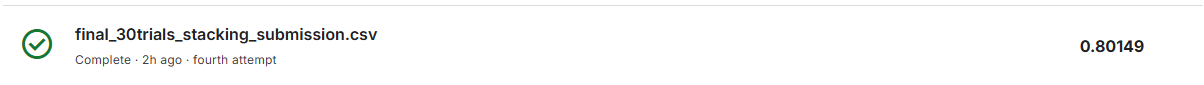

In [39]:
import time
import numpy as np
import pandas as pd
import optuna
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import ExtraTreesClassifier, HistGradientBoostingClassifier, StackingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
import warnings
warnings.filterwarnings('ignore')

optuna.logging.set_verbosity(optuna.logging.WARNING)

# =========================================================================
# 1단계: 고급 전처리 (로그 변환 및 교차 변수 추가)
# =========================================================================
print("▶ 1. 로그 변환 및 파생 변수 생성을 포함한 고급 전처리 시작...")

def preprocess_advanced(df):
    df_clean = df.copy()

    # 지출 항목 정의
    spend_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

    # 총 지출액(TotalSpend) 계산 (결측치는 0으로 임시 계산하여 총합 도출)
    df_clean['TotalSpend'] = df_clean[spend_cols].fillna(0).sum(axis=1)
    df_clean['NoSpend'] = (df_clean['TotalSpend'] == 0).astype(int)

    # 동면(CryoSleep) 논리적 복원
    cryo_logic = (df_clean['TotalSpend'] == 0)
    df_clean['CryoSleep'] = df_clean['CryoSleep'].fillna(cryo_logic)

    # [★핵심] 1위 노트북 기법: 지출 데이터 로그 변환 (비대칭 분포 해소)
    for col in spend_cols:
        df_clean[f'Log_{col}'] = np.log1p(df_clean[col].astype(float))
    df_clean['Log_TotalSpend'] = np.log1p(df_clean['TotalSpend'].astype(float))

    # [★핵심] 1위 노트북 기법: 나이와 지출액의 상호작용 변수 추가
    df_clean['AgeSpendInteraction'] = df_clean['Age'] * df_clean['TotalSpend']

    # 그룹 및 객실 분해
    df_clean['GroupId'] = df_clean['PassengerId'].apply(lambda x: str(x).split('_')[0]) # Fix: Added [0] to make GroupId hashable
    group_size = df_clean['GroupId'].value_counts().to_dict()
    df_clean['GroupSize'] = df_clean['GroupId'].map(group_size)

    df_clean[['Deck', 'Cabin_num', 'Side']] = df_clean['Cabin'].str.split('/', expand=True)

    df_clean['LastName'] = df_clean['Name'].fillna('Unknown').apply(lambda x: str(x).split(' ')[-1])
    df_clean['FamilyId'] = df_clean['LastName'] + '_' + df_clean['Deck'].fillna('U') + '_' + df_clean['Side'].fillna('U')
    family_size = df_clean['FamilyId'].value_counts().to_dict()
    df_clean['FamilySize'] = df_clean['FamilyId'].map(family_size)

    invalid_family = (df_clean['LastName'] == 'Unknown') | (df_clean['Deck'].isnull())
    df_clean.loc[invalid_family, 'FamilySize'] = 1

    # 분석에 불필요한 기존 텍스트/원본 컬럼 완전 삭제 (TF-IDF 배제)
    cols_to_drop = ['Cabin', 'Name', 'GroupId', 'LastName', 'FamilyId'] + spend_cols
    df_clean = df_clean.drop(columns=cols_to_drop, errors='ignore')

    return df_clean

# 데이터에 함수 적용
train_clean_v3 = preprocess_advanced(train_df)
test_clean_v3 = preprocess_advanced(test_df)

y_train = train_clean_v3['Transported'].astype(int)
X_train = train_clean_v3.drop(['PassengerId', 'Transported'], axis=1)
X_test = test_clean_v3.drop(['PassengerId'], axis=1)


# =========================================================================
# 2단계: 파이프라인 (KNN Imputer 도입)
# =========================================================================
print("▶ 2. 파이프라인 구축 (KNN Imputer 적용) 중...")

num_cols = ['Age', 'Log_RoomService', 'Log_FoodCourt', 'Log_ShoppingMall', 'Log_Spa', 'Log_VRDeck',
            'TotalSpend', 'Log_TotalSpend', 'AgeSpendInteraction', 'GroupSize', 'FamilySize']
cat_cols = ['HomePlanet', 'Destination', 'CryoSleep', 'VIP', 'Deck', 'Cabin_num', 'Side', 'NoSpend']

# [★핵심] 3위 노트북 기법: 수치형 결측치를 중앙값이 아닌 KNN 알고리즘으로 정교하게 유추하여 채움
num_pipeline = Pipeline([
    ('imputer', KNNImputer(n_neighbors=5)),
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor_v3 = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

X_train_processed_v3 = preprocessor_v3.fit_transform(X_train)
X_test_processed_v3 = preprocessor_v3.transform(X_test)
print(f"✔️ 데이터 변환 완료! (최종 데이터 형태: {X_train_processed_v3.shape})\n")


# =========================================================================
# 3단계: 5중 앙상블 모델 최적화 및 스태킹
# =========================================================================
print("▶ 3. 5개 모델(XGB, LGBM, CAT, ExtraTrees, HistGBM) 최적화 시작...")
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
total_start = time.time()

# 1. XGBoost
def objective_xgb(trial):
    params = {'n_estimators': trial.suggest_int('n_estimators', 100, 300),
              'max_depth': trial.suggest_int('max_depth', 3, 9),
              'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1)}
    model = XGBClassifier(**params, eval_metric='logloss', random_state=42)
    return cross_val_score(model, X_train_processed_v3, y_train, cv=cv, scoring='accuracy', n_jobs=-1).mean()

study_xgb = optuna.create_study(direction='maximize')
study_xgb.optimize(objective_xgb, n_trials=15)
best_xgb = XGBClassifier(**study_xgb.best_params, eval_metric='logloss', random_state=42)

# 2. LightGBM
def objective_lgbm(trial):
    params = {'n_estimators': trial.suggest_int('n_estimators', 100, 300),
              'max_depth': trial.suggest_int('max_depth', 3, 9),
              'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1)}
    model = LGBMClassifier(**params, verbose=-1, random_state=42)
    return cross_val_score(model, X_train_processed_v3, y_train, cv=cv, scoring='accuracy', n_jobs=-1).mean()

study_lgbm = optuna.create_study(direction='maximize')
study_lgbm.optimize(objective_lgbm, n_trials=15)
best_lgbm = LGBMClassifier(**study_lgbm.best_params, verbose=-1, random_state=42)

# 3. CatBoost
def objective_cat(trial):
    params = {'iterations': trial.suggest_int('iterations', 100, 300),
              'depth': trial.suggest_int('depth', 3, 9),
              'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1)}
    model = CatBoostClassifier(**params, verbose=0, random_state=42)
    return cross_val_score(model, X_train_processed_v3, y_train, cv=cv, scoring='accuracy', n_jobs=-1).mean()

study_cat = optuna.create_study(direction='maximize')
study_cat.optimize(objective_cat, n_trials=15)
best_cat = CatBoostClassifier(**study_cat.best_params, verbose=0, random_state=42)

# [★새 모델] 4. Extra Trees
def objective_et(trial):
    params = {'n_estimators': trial.suggest_int('n_estimators', 100, 300),
              'max_depth': trial.suggest_int('max_depth', 5, 20)}
    model = ExtraTreesClassifier(**params, random_state=42)
    return cross_val_score(model, X_train_processed_v3, y_train, cv=cv, scoring='accuracy', n_jobs=-1).mean()

study_et = optuna.create_study(direction='maximize')
study_et.optimize(objective_et, n_trials=15)
best_et = ExtraTreesClassifier(**study_et.best_params, random_state=42)

# [★새 모델] 5. HistGradientBoosting
def objective_hgb(trial):
    params = {'max_iter': trial.suggest_int('max_iter', 100, 300),
              'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1)}
    model = HistGradientBoostingClassifier(**params, random_state=42)
    return cross_val_score(model, X_train_processed_v3, y_train, cv=cv, scoring='accuracy', n_jobs=-1).mean()

study_hgb = optuna.create_study(direction='maximize')
study_hgb.optimize(objective_hgb, n_trials=15)
best_hgb = HistGradientBoostingClassifier(**study_hgb.best_params, random_state=42)

print("✔️ 5개 개별 모델 최적화 완료!")

# 스태킹 결합
print("▶ 4. 5개 모델 스태킹 앙상블 학습 중...")
estimators = [
    ('XGB', best_xgb),
    ('LGBM', best_lgbm),
    ('CAT', best_cat),
    ('ET', best_et),
    ('HGB', best_hgb)
]

stacking_model = StackingClassifier(estimators=estimators, final_estimator=LogisticRegression())
stacking_model.fit(X_train_processed_v3, y_train)

# 예측 및 제출
predictions = stacking_model.predict(X_test_processed_v3)
submission_df['Transported'] = predictions.astype(bool)
submission_path = f'{base_path}/advanced_knn_log_stacking_submission.csv'
submission_df.to_csv(submission_path, index=False)

print(f"🎉 성공! 최종 제출 파일 저장 완료: {submission_path}")
print(f"🏆 총 최적화 및 학습 소요 시간: {time.time() - total_start:.2f}초")

▶ 1. 로그 변환 및 파생 변수 생성을 포함한 고급 전처리 시작...
▶ 2. 파이프라인 구축 (KNN Imputer 적용) 중...
✔️ 데이터 변환 완료! (최종 데이터 형태: (8693, 1850))

▶ 3. 5개 모델(XGB, LGBM, CAT, ExtraTrees, HistGBM) 최적화 시작...
✔️ 5개 개별 모델 최적화 완료!
▶ 4. 5개 모델 스태킹 앙상블 학습 중...
🎉 성공! 최종 제출 파일 저장 완료: /content/drive/MyDrive/Colab Notebooks/main_quest/spaceship-titanic/advanced_knn_log_stacking_submission.csv
🏆 총 최적화 및 학습 소요 시간: 5113.05초


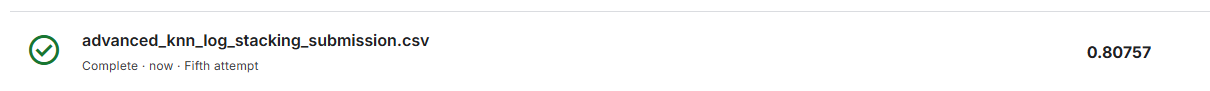



---



# 마. 참고 문헌 (Reference)
1. Addison Howard, Ashley Chow, and Ryan Holbrook. Spaceship Titanic. https://kaggle.com/competitions/spaceship-titanic, 2022. Kaggle.
2. Maxim. E2E Pipeline: Optuna and Stacking | Spaceship. https://kaggle.com/competitions/spaceship-titanic, Kaggle.
3. Minato Namikaze. 🛸 Space Titanic| EDA| Advanced Feature Engineering. https://kaggle.com/competitions/spaceship-titanic, Kaggle.
4. Ravi Ramakrishnan. SpaceshipTitanic| Models| V2. https://kaggle.com/competitions/spaceship-titanic, Kaggle